In [68]:
import pandas as pd

In [69]:
df = pd.read_csv('csv/resource-movements.csv')
print(df.head()) #returns first 5 rows of the df


                   territory  country   resource  discovery_year     movement  \
0             Eastern Region  Nigeria        Oil            1967  Biafra/NCNC   
1                  Ogoniland  Nigeria        Oil            1958        MOSOP   
2                    Cabinda   Angola        Oil            1966         FLEC   
3                South Sudan   Sudan         Oil            1978         SPLM   
4  Western Sahara (Bou Craa)  Morocco  Phosphate            1947    Polisario   

   movement_year  
0           1967  
1           1990  
2           1963  
3           1983  
4           1973  


In [70]:
print(df.dtypes) #returns a series containg the data types of every column


territory         object
country           object
resource          object
discovery_year     int64
movement          object
movement_year      int64
dtype: object


Calculate the Gap 

In [71]:

print(df[['discovery_year', 'movement_year']].head(10))

   discovery_year  movement_year
0            1967           1967
1            1958           1990
2            1966           1963
3            1978           1983
4            1947           1973
5            1906           1960
6            1980           1981
7            1956           1988


In [72]:
df['years_gap'] = df['movement_year'] - df['discovery_year']
print(df[['territory', 'discovery_year', 'movement_year', 'years_gap']])

                   territory  discovery_year  movement_year  years_gap
0             Eastern Region            1967           1967          0
1                  Ogoniland            1958           1990         32
2                    Cabinda            1966           1963         -3
3                South Sudan            1978           1983          5
4  Western Sahara (Bou Craa)            1947           1973         26
5                    Katanga            1906           1960         54
6                 Somaliland            1980           1981          1
7                Niger Delts            1956           1988         32


First Plot: simple scatter

In [73]:
import matplotlib.pyplot as plt

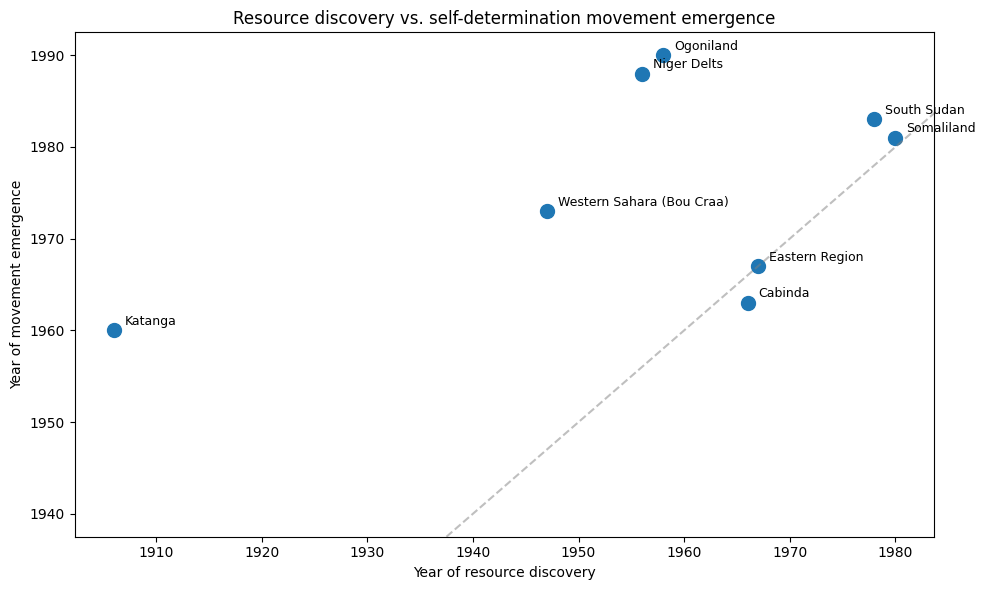

In [74]:
plt.figure(figsize=(10,6))
plt.scatter(df['discovery_year'], df['movement_year'], s=100)

for _, row in df.iterrows(): #iterate through rows
    plt.annotate(row['territory'], 
                (row['discovery_year'], row['movement_year']),
                 textcoords="offset points", xytext=(8,4), fontsize=9)
    
plt.xlabel('Year of resource discovery')
plt.ylabel('Year of movement emergence')
plt.title('Resource discovery vs. self-determination movement emergence')

# Add diagonal reference line (discovery = movement, i.e. zero lag)
plt.axline((1940, 1940), slope=1, linestyle='--', color='gray', alpha=0.5)

plt.tight_layout()
plt.savefig('scatter_plot_resource_movement_simple.png', dpi=150)
plt.show()

Better Plot?

In [75]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

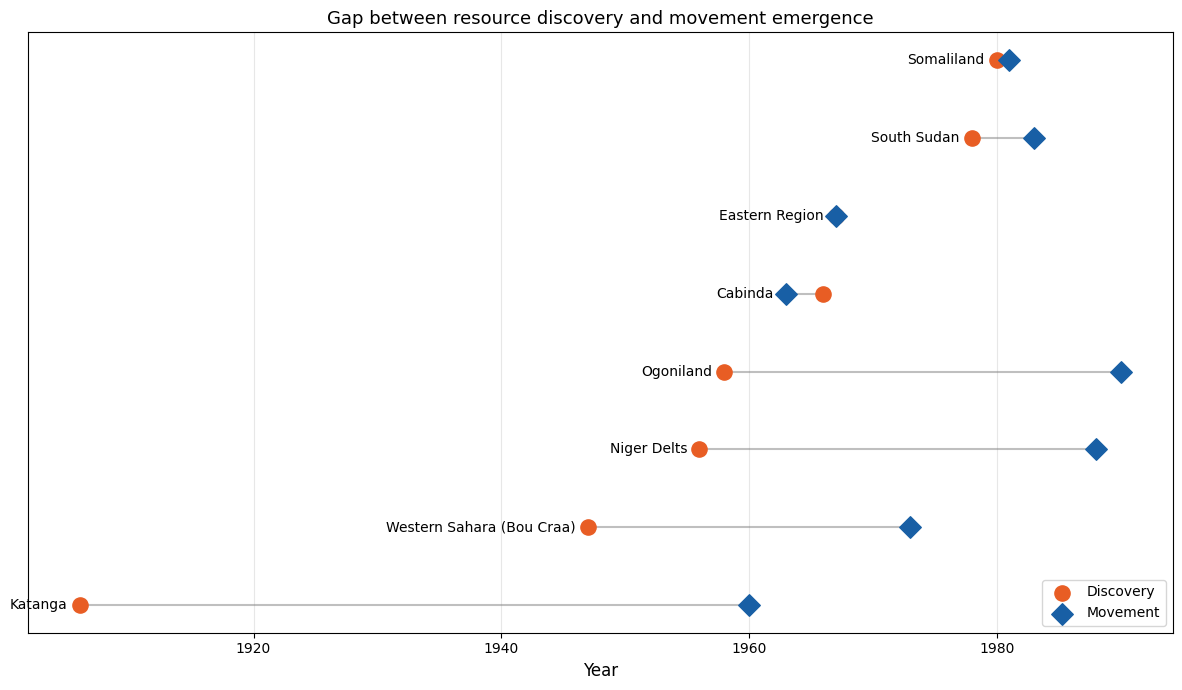

In [76]:
df_sorted = df.sort_values('discovery_year')

fig, ax = plt.subplots(figsize=(12, 7))

for i, row in enumerate(df_sorted.itertuples()):
    # Draw resource discovery marker
    ax.scatter(row.discovery_year, i, color='#E85D24', s=120, zorder=5, label='Discovery' if i==0 else '')
    # Draw movement emergence marker  
    ax.scatter(row.movement_year, i, color='#185FA5', s=120, marker='D', zorder=5, label='Movement' if i==0 else '')
    # Draw connecting line
    ax.plot([row.discovery_year, row.movement_year], [i, i], 
            color='gray', linewidth=1.5, alpha=0.5)
    # Label
    ax.text(min(row.discovery_year, row.movement_year) - 1, i, 
            row.territory, ha='right', va='center', fontsize=10)

ax.set_yticks([])
ax.set_xlabel('Year', fontsize=12)
ax.set_title('Gap between resource discovery and movement emergence', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('timeline.png', dpi=150)
plt.show()